# LIBRARY

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_curve, auc
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from scikitplot.metrics import plot_roc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd
import gzip 
import pickle 
from collections import Counter
import matplotlib.pyplot as plt
import gzip
import pickle
import sys
import numpy as np
import warnings
import pandas as pd
from scipy.stats import levene
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", InterpolationWarning)
warnings.simplefilter("ignore", UserWarning)
from collections import Counter


# DATAFRAMES

In [75]:
with gzip.open("../1.DATASET/CMI_timeseries_personalized.pkl.gz", "rb") as f:
	 CMI_timeseries_personalized = pickle.load(f)

In [76]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_personalized)}")

Number of time series: 4307


## Cleaning

In [77]:
df = CMI_timeseries_personalized[0].copy()
df.columns

Index(['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light',
       'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id',
       'sii_binary'],
      dtype='object')

In [78]:
cols_to_drop = ["battery_voltage", "timestamp", "quarter", "relative_date_PCIAT"]
data_clean   = [df.drop(columns=cols_to_drop, errors="ignore") for df in CMI_timeseries_personalized]

print(f"Columns remaining: {data_clean[0].columns.tolist()}")
print(f"Total subjects   : {len(data_clean)}")

Columns remaining: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'weekday', 'id', 'sii_binary']
Total subjects   : 4307


## id check

In [79]:
all_labels = [df["sii_binary"].iloc[0] for df in data_clean]
all_ids    = [df["id"].iloc[0]         for df in data_clean]

# Filter missing labels
valid_idx    = [i for i, label in enumerate(all_labels) if not pd.isna(label)]
valid_labels = np.array([all_labels[i] for i in valid_idx])
valid_ids    = np.array([all_ids[i]    for i in valid_idx])

print(f"Total datasets          : {len(data_clean)}")
print(f"Valid (non-null label)  : {len(valid_idx)}")
print(f"Unique subject IDs      : {len(set(valid_ids))}")

Total datasets          : 4307
Valid (non-null label)  : 4307
Unique subject IDs      : 372


## split 

In [80]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_pos, test_pos = next(gss.split(
    X=valid_idx,
    y=valid_labels,
    groups=valid_ids
))

train_idx = [valid_idx[i] for i in train_pos]
test_idx  = [valid_idx[i] for i in test_pos]

train_dfs = [data_clean[i] for i in train_idx]
test_dfs  = [data_clean[i] for i in test_idx]

In [81]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
train_ids = set(df["id"].iloc[0] for df in train_dfs)
test_ids  = set(df["id"].iloc[0] for df in test_dfs)
overlap   = train_ids & test_ids

print(f"\nTrain datasets  : {len(train_dfs)}")
print(f"Test datasets   : {len(test_dfs)}")
print(f"Total           : {len(train_dfs) + len(test_dfs)}")
print(f"Subject ID overlap (must be 0): {len(overlap)}")


Train datasets  : 3298
Test datasets   : 1009
Total           : 4307
Subject ID overlap (must be 0): 0


# NORMALIZATION

In [82]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light", "non-wear_flag", "weekday"]

In [83]:
def fit_global_scalers(df_list, signals):
    """Fit one RobustScaler per signal using TRAIN data only."""
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers


In [84]:
def apply_global_scalers(df_list, global_scalers):
    """Apply pre-fitted scalers to a list of DataFrames."""
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list


In [85]:

global_scalers = fit_global_scalers(train_dfs, signals)
train_scaled   = apply_global_scalers(train_dfs, global_scalers)
test_scaled    = apply_global_scalers(test_dfs,  global_scalers)

print(f"\nTrain scaled: {len(train_scaled)} | Test scaled: {len(test_scaled)}")

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8217)
  Y                  → RobustScaler   (IQR=0.4166)
  Z                  → RobustScaler   (IQR=0.4350)
  enmo               → RobustScaler   (IQR=0.0463)
  anglez             → RobustScaler   (IQR=5.6673)
  light              → RobustScaler   (IQR=1.8472)
  non-wear_flag      → RobustScaler   (IQR=1.0000)

Train scaled: 3298 | Test scaled: 1009


## split

In [86]:
FEATURE_SIGNALS = ["X", "Y", "Z", "enmo", "anglez", "non-wear_flag", "light", "weekday"]
TARGET_SIGNAL   = "sii_binary"

def build_Xy(df_list, feature_signals, target_signal):
    X_list, y_list = [], []
    for df in df_list:
        target_value = df[target_signal].iloc[0]
        if pd.isna(target_value):
            continue
        row = {s: pd.Series(df[s].values) for s in feature_signals if s in df.columns}
        X_list.append(row)
        y_list.append(int(target_value))
    return pd.DataFrame(X_list), np.array(y_list)

X_train, y_train = build_Xy(train_scaled, FEATURE_SIGNALS, TARGET_SIGNAL)
X_test,  y_test  = build_Xy(test_scaled,  FEATURE_SIGNALS, TARGET_SIGNAL)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train balance: {np.bincount(y_train)}")
print(f"y_test  balance: {np.bincount(y_test)}")

X_train: (3298, 8) | X_test: (1009, 8)
y_train balance: [2163 1135]
y_test  balance: [724 285]


In [87]:
X_train.head(5)


,X,Y,Z,enmo,anglez,non-wear_flag,light,weekday
0,0 -0.362916 1 -0.195976 2 -0.16357...,0 -0.147957 1 0.517750 2 -0.41849...,0 0.054546 1 -0.338792 2 -0.40336...,0 0.421326 1 0.655773 2 1.81464...,0 0.049123 1 -0.141571 2 -0.16635...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 0.549546 1 0.526281 2 -0.06727...,0 4.0 1 4.0 2 4.0 3 4.0 4 ...
1,0 1.062204 1 1.080659 2 -0.15136...,0 -0.834759 1 -0.794093 2 -0.56004...,0 0.736609 1 0.439905 2 1.05116...,0 -0.256505 1 -0.225628 2 -0.43175...,0 0.866481 1 0.707613 2 0.97513...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 -0.532352 1 -0.528763 2 -0.52691...,0 1.0 1 1.0 2 1.0 3 1.0 4 ...
2,0 1.016709 1 -0.397746 2 -0.53783...,0 -0.626197 1 -0.385424 2 -0.47791...,0 1.215976 1 -0.197581 2 0.18493...,0 -0.088625 1 -0.472020 2 -0.58418...,0 1.005960 1 -0.078117 2 0.23276...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 1.459738 1 1.452811 2 1.44175...,0 3.0 1 3.0 2 3.0 3 3.0 4 ...
3,0 0.466793 1 0.437749 2 0.59050...,0 0.189711 1 0.034730 2 0.35276...,0 2.450671 1 2.558863 2 0.58158...,0 -0.169150 1 -0.348129 2 -0.26461...,0 1.164293 1 1.175778 2 0.87198...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 -0.659260 1 -0.656805 2 -0.64191...,0 5.0 1 5.0 2 5.0 3 5.0 4 ...
4,0 0.934145 1 0.087142 2 0.83957...,0 0.708510 1 0.238960 2 -0.13844...,0 0.465337 1 0.284776 2 -0.77726...,0 1.772592 1 0.449817 2 -0.59821...,0 0.715052 1 0.264084 2 -0.24228...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 0.450971 1 0.450971 2 0.45097...,0 5.0 1 5.0 2 5.0 3 5.0 4 ...


In [88]:
y_train.shape

(3298,)

In [89]:
# ── VERIFY BEFORE FITTING ─────────────────────────────────────────────────────

# 1. Shape
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

# 2. Cell type — must be pd.Series
print("Cell type     :", type(X_train.iloc[0, 0]))

# 3. All time series same length — KNN requires this
lengths = [[len(X_train.iloc[i, j]) for j in range(X_train.shape[1])]
           for i in range(min(10, len(X_train)))]
flat    = [l for row in lengths for l in row]
print("Unique lengths:", set(flat))          # must be exactly ONE value

# 4. No NaN inside any series
has_nan = any(X_train.iloc[i, j].isna().any()
              for i in range(len(X_train))
              for j in range(X_train.shape[1]))
print("Any NaN in X  :", has_nan)            # must be False

# 5. Class balance
print("y_train balance:", np.bincount(y_train))
print("y_test  balance:", np.bincount(y_test))

X_train shape : (3298, 8)
X_test shape  : (1009, 8)
Cell type     : <class 'pandas.core.series.Series'>
Unique lengths: {200}
Any NaN in X  : False
y_train balance: [2163 1135]
y_test  balance: [724 285]


# KNN

## euclidean

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold

random_state = 42

param_list = {
    'n_neighbors': [4, 8, 16, 32, 64, 128],
    'weights': ['uniform', 'distance','balanced'],
    'distance': ['euclidean'],
    'n_jobs': [-1]
}

random_search = RandomizedSearchCV(
    KNeighborsTimeSeriesClassifier(),
    param_distributions = param_list,
    cv                  = KFold(n_splits=5, shuffle=True, random_state=random_state),
    scoring             = 'f1_macro', 
    n_jobs              = -1,
    refit               = True,
    n_iter              = 5,
    random_state        = random_state
)

random_search.fit(X_train, y_train)
print(f"Best params : {random_search.best_params_}")
print(f"Best CV f1  : {random_search.best_score_:.4f}")



c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ESTER\anaconda3\Lib\site-packages\sktime\classification\base.py", line 264, in fit
    self._fit(X, y)
  File "c:\Users\ESTER\anaconda3\Lib\site-packages\sktime\base\_panel\knn.py", line 117, in _fit
    return self._fit_precomp(X=X, y=y)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users

Best params : {'weights': 'distance', 'n_neighbors': 4, 'n_jobs': -1, 'distance': 'euclidean'}
Best CV f1  : 0.5770


In [ ]:
print(f"Best params : {random_search.best_params_}")
print(f"Best CV f1  : {random_search.best_score_:.4f}")

Best params : {'weights': 'distance', 'n_neighbors': 4, 'n_jobs': -1, 'distance': 'euclidean'}
Best CV f1  : 0.5770


  Model       : KNN EUCLIDEAN
  Test F1     : 0.5950


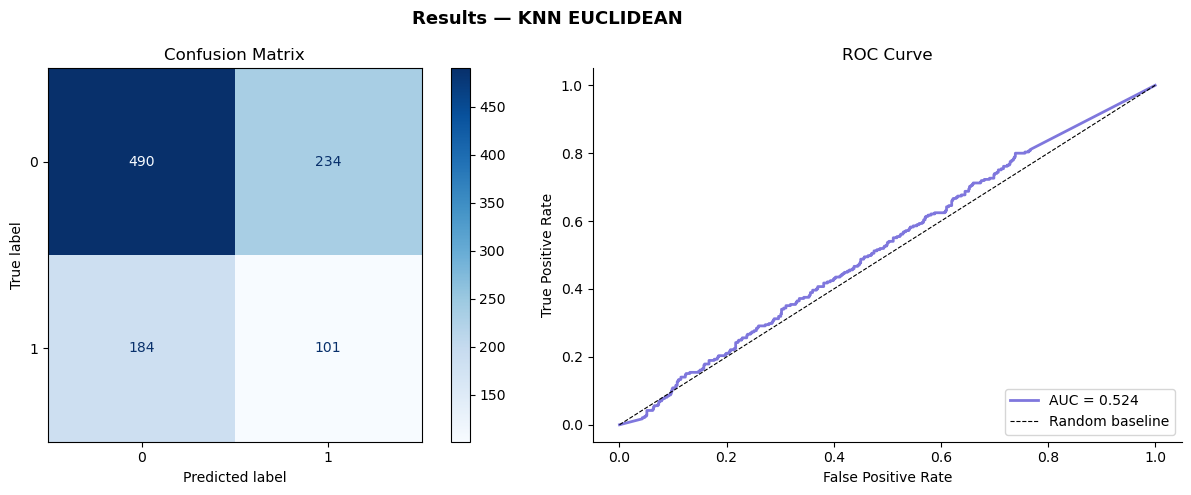

              precision    recall  f1-score   support

     Class 0       0.73      0.68      0.70       724
     Class 1       0.30      0.35      0.33       285

    accuracy                           0.59      1009
   macro avg       0.51      0.52      0.51      1009
weighted avg       0.61      0.59      0.60      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 490
    FP (false positives)   : 234
    FN (false negatives)   : 184
    TP (correct positives) : 101
    AUC                    : 0.5236


In [ ]:
print_classification_results(
    best_model  = random_search.best_estimator_,
    X_test      = X_test,
    y_test      = y_test,
    model_name  = "KNN EUCLIDEAN"
)

## DTW 

In [ ]:
random_state = 42

param_list = {
    "n_neighbors" : [4],
    "weights"     : ["distance","balanced"],
    "distance"    : ["dtw"],
    "distance_params": [
        {"window": 0.05},   # very tight band — 10 steps
        {"window": 0.10},   # standard recommendation — 20 steps
        {"window": 0.20},   # looser — 40 steps
    ],
    "n_jobs": [-1]
}

random_search_dtw = RandomizedSearchCV(
    KNeighborsTimeSeriesClassifier(),
    param_distributions = param_list,
    cv                  = KFold(n_splits=5, shuffle=True, random_state=random_state),
    scoring             = "f1_macro",
    n_jobs              = -1,
    refit               = True,
    n_iter              = 3,            # one per window size
    random_state        = random_state
)

random_search_dtw.fit(X_train, y_train)
print(f"Best params : {random_search.best_params_}")
print(f"Best CV f1  : {random_search.best_score_:.4f}")

c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ESTER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ESTER\anaconda3\Lib\site-packages\sktime\classification\base.py", line 264, in fit
    self._fit(X, y)
  File "c:\Users\ESTER\anaconda3\Lib\site-packages\sktime\base\_panel\knn.py", line 117, in _fit
    return self._fit_precomp(X=X, y=y)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users

Best params : {'weights': 'distance', 'n_neighbors': 4, 'n_jobs': -1, 'distance': 'euclidean'}
Best CV f1  : 0.5770


  Model       : KNN DTM
  Test F1     : 0.6013


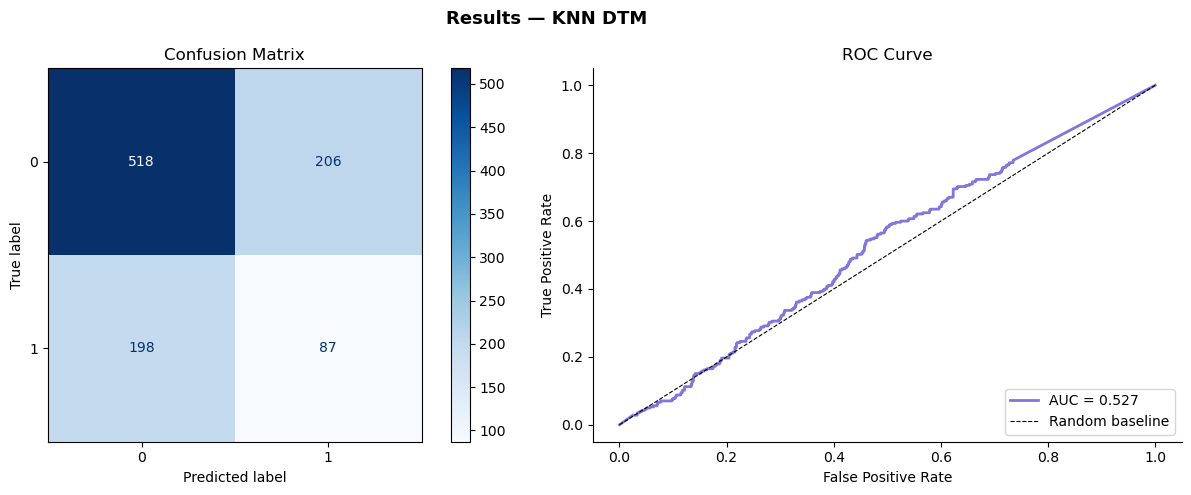

              precision    recall  f1-score   support

     Class 0       0.72      0.72      0.72       724
     Class 1       0.30      0.31      0.30       285

    accuracy                           0.60      1009
   macro avg       0.51      0.51      0.51      1009
weighted avg       0.60      0.60      0.60      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 518
    FP (false positives)   : 206
    FN (false negatives)   : 198
    TP (correct positives) : 87
    AUC                    : 0.5268


In [ ]:
print_classification_results(
    best_model  = random_search_dtw.best_estimator_,
    X_test      = X_test,
    y_test      = y_test,
    model_name  = "KNN DTM"
)

## DTW 

In [ ]:
random_state = 42

param_list = {
    "n_neighbors" : [4],
    "weights"     : ["distance"],
    "distance"    : ["dtw"],
    "distance_params": [
        {"window": 0.05},   # very tight band — 10 steps
        {"window": 0.10},   # standard recommendation — 20 steps
        {"window": 0.20},   # looser — 40 steps
    ],
    "n_jobs": [-1]
}

random_search_dtw = RandomizedSearchCV(
    KNeighborsTimeSeriesClassifier(),
    param_distributions = param_list,
    cv                  = KFold(n_splits=5, shuffle=True, random_state=random_state),
    scoring             = "f1_macro",
    n_jobs              = -1,
    refit               = True,
    n_iter              = 3,            # one per window size
    random_state        = random_state
)

random_search_dtw.fit(X_train, y_train)

In [ ]:
# ── EVALUATE ──────────────────────────────────────────────────────────────────


y_pred_dtw = random_search_dtw.predict(X_test)

print("Best params  :", random_search_dtw.best_params_)
print("Best CV f1   :", round(random_search_dtw.best_score_, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtw))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtw))

In [ ]:
print_classification_results(
    best_model  = random_search_dtw.best_estimator_,
    X_test      = X_test,
    y_test      = y_test,
    model_name  = "KNN DTM"
)

# SHAPELETS

## convert df in 3d df

In [90]:
# Drop unwanted channels. they carry no information for shapelets
cols_to_drop = ["weekday", "non-wear_flag"] 

X_train_filtered = X_train.drop(columns=cols_to_drop)
X_test_filtered  = X_test.drop(columns=cols_to_drop)

print(f"Remaining channels: {list(X_train_filtered.columns)}")  # → 6 channels

# Convert to 3D numpy array
X_train_3d = np.stack([
    np.stack(X_train_filtered.iloc[i].values)
    for i in range(len(X_train_filtered))
])  # → (n_samples, 6, 200)

X_test_3d = np.stack([
    np.stack(X_test_filtered.iloc[i].values)
    for i in range(len(X_test_filtered))
])

print(f"X_train_3d: {X_train_3d.shape}")  # → (3298, 6, 200)
print(f"X_test_3d:  {X_test_3d.shape}")   # → (1009, 6, 200)
print(type(X_train_3d))

Remaining channels: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
X_train_3d: (3298, 6, 200)
X_test_3d:  (1009, 6, 200)
<class 'numpy.ndarray'>


## shapelets fit and transform (multivariate case)

In [91]:
from aeon.transformations.collection.shapelet_based import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np

rst = RandomShapeletTransform(
    n_shapelet_samples=1000,   # How many candidate shapelets to evaluate during search
    max_shapelets=200,         # Max shapelets kept after filtering (become features)
    min_shapelet_length=4,     # Shortest subsequence to consider
    max_shapelet_length=30,    # Longest subsequence to consider
    n_jobs=-1,
    # In multivariate mode, shapelets are extracted from ONE channel at a time.
    # The transform records BOTH the best distance AND which channel it came from.
)

In [92]:
%%time
rst.fit(X_train_3d, y_train)
# ↑ Searches across all channels for the most discriminative subsequences.
#   With n_channels > 1, the search space is n_channels × n_timepoints wide.

CPU times: user 43min 54s, sys: 34.3 s, total: 44min 28s
Wall time: 44min 50s


RandomShapeletTransform(max_shapelet_length=30, max_shapelets=200,
                        min_shapelet_length=4, n_jobs=-1,
                        n_shapelet_samples=1000)

In [93]:
%%time
shapelets_distances_train = rst.transform(X_train_3d)
shapelets_distances_test  = rst.transform(X_test_3d)

# Output shape: (n_samples, max_shapelets) for BOTH uni- and multivariate
# Each column = min distance from that sample to one discovered shapelet
print(shapelets_distances_train.shape)  # e.g. (8000, 200)
print(shapelets_distances_test.shape)   # e.g. (2000, 200)

(3298, 200)
(1009, 200)
CPU times: user 1min 25s, sys: 13 s, total: 1min 38s
Wall time: 2min


In [94]:
# Saving everything 
np.save('../1.DATASET/shapelets.npy', np.array(rst.shapelets, dtype=object))
# 
np.save('../1.DATASET/shapelets_distances_train.npy', shapelets_distances_train)
np.save('../1.DATASET/shapelets_distances_test.npy', shapelets_distances_test)

In [95]:
from collections import Counter

# Channels actually used by the shapelet transform
filtered_signals = list(X_train_filtered.columns)

# How many shapelets were found
print(f"Total shapelets: {len(rst.shapelets)}")

# Inspect the first shapelet
ig, length, start, channel, instance_idx, class_val, values = rst.shapelets[0]

print(f"Info gain  : {ig:.4f}")
print(f"Length     : {length}")
print(f"Start pos  : {start}")
print(f"Channel    : {channel} → {filtered_signals[channel]}")
print(f"From sample: {instance_idx} (class {class_val})")
print(f"Values     : {values}")

# Count shapelets by channel
channel_counts = Counter(s[3] for s in rst.shapelets)

print("\nShapelets per channel:")
for ch, count in sorted(channel_counts.items()):
    print(f"  Channel {ch} ({filtered_signals[ch]}): {count} shapelets")

Total shapelets: 200
Info gain  : 0.0771
Length     : 4
Start pos  : 175
Channel    : 5 → light
From sample: 317 (class 0)
Values     : [0. 0. 0. 0.]

Shapelets per channel:
  Channel 0 (X): 29 shapelets
  Channel 1 (Y): 17 shapelets
  Channel 2 (Z): 14 shapelets
  Channel 3 (enmo): 30 shapelets
  Channel 4 (anglez): 31 shapelets
  Channel 5 (light): 79 shapelets


## train DT on shapelets dataset

In [96]:
%%time

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [8, 16, 32, 64, 128, 256, 512] + [None],
    'min_samples_split': [4, 8, 16, 32, 64, 128, 256],
    'min_samples_leaf': [4, 8, 16, 32, 64, 128, 256],
}

rand_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    param_distributions=param_dist,
    cv=KFold(n_splits=4, shuffle=True, random_state=42),
    scoring='f1_macro',             
    n_jobs=-1,
    refit=True,
    verbose=1,
    n_iter=50,
    random_state=42
)

rand_search.fit(shapelets_distances_train, y_train)
dec_tree = rand_search.best_estimator_

Fitting 4 folds for each of 50 candidates, totalling 200 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (

CPU times: user 976 ms, sys: 211 ms, total: 1.19 s
Wall time: 27.9 s


In [97]:
y_pred = rand_search.predict(shapelets_distances_test)

print("Best params  :", rand_search.best_params_)
print("Best CV f1   :", round(rand_search.best_score_, 4))

Best params  : {'min_samples_split': 256, 'min_samples_leaf': 256, 'max_depth': 128, 'criterion': 'gini'}
Best CV f1   : 0.5305


  Model       : Shapelet + Decision Tree
  Test F1     : 0.5386


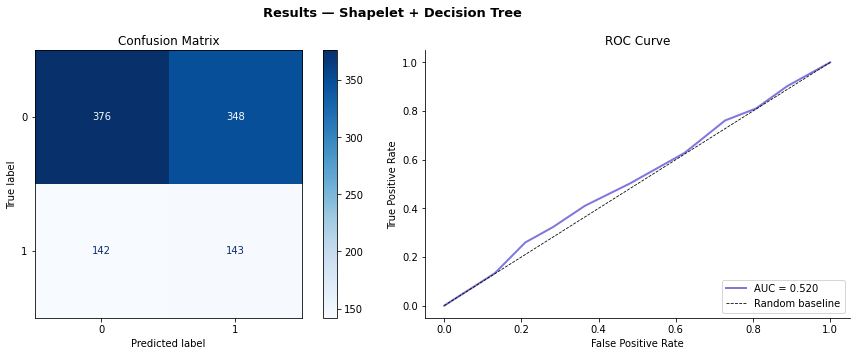

              precision    recall  f1-score   support

     Class 0       0.73      0.52      0.61       724
     Class 1       0.29      0.50      0.37       285

    accuracy                           0.51      1009
   macro avg       0.51      0.51      0.49      1009
weighted avg       0.60      0.51      0.54      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 376
    FP (false positives)   : 348
    FN (false negatives)   : 142
    TP (correct positives) : 143
    AUC                    : 0.5197


In [98]:
print_classification_results(
    best_model  = dec_tree,                   # best estimator from grid_search
    X_test      = shapelets_distances_test,   # ← distance matrix, NOT raw 3D array
    y_test      = y_test,
    model_name  = "Shapelet + Decision Tree"
)

# MINIROCKET

In [ ]:
from sktime.classification.kernel_based import RocketClassifier

In [18]:
param_distributions = {
    "rocket_transform": ["minirocket"], 
    "num_kernels": [1000, 2000, 4000, 6000, 8000, 10000],
    "max_dilations_per_kernel": [4, 8, 16, 32, 64],
    "n_jobs": [-1], # Ensure the underlying transformer uses all cores
}

random_search = RandomizedSearchCV(
    estimator=RocketClassifier(),
    param_distributions=param_distributions,
    n_iter=10, 
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=42),
    scoring="f1_macro", 
    n_jobs=1,
    refit=True,
    random_state=42
)


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


In [19]:
random_search.fit(X_train, y_train)
best_rocket = random_search.best_estimator_
print(f"Best params : {random_search.best_params_}")
print(f"Best CV f1  : {random_search.best_score_:.4f}")

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set

Best params : {'rocket_transform': 'minirocket', 'num_kernels': 6000, 'n_jobs': -1, 'max_dilations_per_kernel': 16}
Best CV f1  : 0.6231


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


  Model       : ROCKET — Randomized Multivariate
  Test F1     : 0.6341


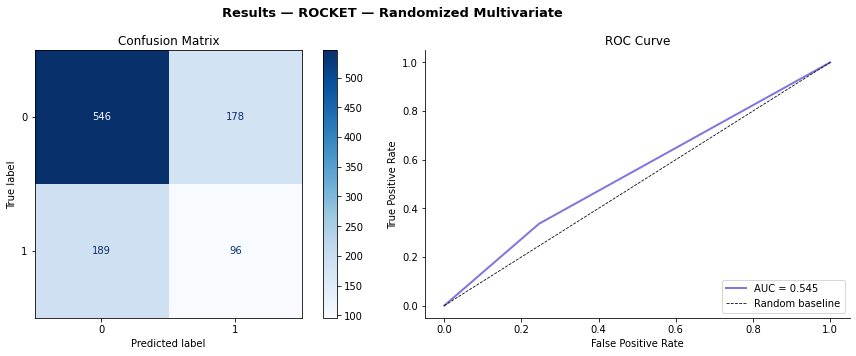

              precision    recall  f1-score   support

     Class 0       0.74      0.75      0.75       724
     Class 1       0.35      0.34      0.34       285

    accuracy                           0.64      1009
   macro avg       0.55      0.55      0.55      1009
weighted avg       0.63      0.64      0.63      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 546
    FP (false positives)   : 178
    FN (false negatives)   : 189
    TP (correct positives) : 96
    AUC                    : 0.5455


In [22]:
print_classification_results(
    best_model=best_rocket,
    X_test=X_test,
    y_test=y_test,
    model_name="ROCKET — Randomized Multivariate"
)